In [140]:
import pandas as pd
import numpy as np
import os

In [141]:
your_flood_date = '2023-08-08 09:20:00'
flood_duration_days = 5
stage_data_file = '../../Data/Discharge-DHM/Bagmati at Khokana_River Water Level Inst_1990-01-01_2025-03-27_Point.csv'
rating_table_file = '../../Data/Stage/RT_550.05.txt'
output_path = '../../Results/Floods/Flood_Event/'
model_output_file = "../../Models/Base Model/base.otl"
precip_data_file = '../../Results/Floods/Flood_Event/prec_202308_202308.csv'
flood_peak_date = pd.to_datetime(your_flood_date)
flood_start_date = (flood_peak_date - pd.Timedelta(days=(flood_duration_days-1)/2)).strftime('%Y-%m-%d 00:15:00')
flood_end_date = (flood_peak_date + pd.Timedelta(days=(flood_duration_days-1)/2)).strftime('%Y-%m-%d 00:15:00')

In [142]:
# Load discharge/stage data and filter for flood period
print("🌊 LOADING DISCHARGE DATA FOR FLOOD PERIOD")
print("=" * 60)

# Define file paths

# Load stage data
print("📊 Loading stage data...")
stage_data = pd.read_csv(stage_data_file)

# Clean and prepare stage data
stage_data['dateTime'] = pd.to_datetime(stage_data['dateTime'], format='%m/%d/%Y %H:%M:%S')
stage_data = stage_data.dropna(subset=['value'])
stage_data = stage_data[stage_data['value'] != '']
stage_data = stage_data[pd.to_numeric(stage_data['value'], errors='coerce').notna()]
stage_data['stage_m'] = pd.to_numeric(stage_data['value'])

# Remove unrealistic values
stage_data = stage_data[stage_data['stage_m'] >= 0]
stage_data = stage_data[stage_data['stage_m'] <= 10.0]
stage_data = stage_data[stage_data['stage_m'] != -9999990]

# Load rating table for stage-discharge conversion
rating_data = []

with open(rating_table_file, 'r') as f:
    lines = f.readlines()
    
# Parse rating table (skip header lines)
for line in lines:
    line = line.strip()
    if ',' in line and not line.startswith('Station') and not line.startswith('Data') and not line.startswith('Rating') and not line.startswith('From') and not line.startswith('-'):
        try:
            stage, discharge = line.split(',')
            rating_data.append({
                'stage_m': float(stage),
                'discharge_m3s': float(discharge)
            })
        except:
            continue

rating_df = pd.DataFrame(rating_data)

flood_mask = (stage_data['dateTime'] >= flood_start_date) & (stage_data['dateTime'] <= flood_end_date)
flood_stage_data = stage_data[flood_mask].copy()

if flood_stage_data.empty:
    print("❌ No stage data found for the specified flood period!")
else:
    
    # Convert stage to discharge using rating table (interpolation)
    print(f"\n🔄 Converting stage to discharge...")
    
    # Create interpolation function
    from scipy.interpolate import interp1d
    
    # Sort rating table by stage
    rating_df_sorted = rating_df.sort_values('stage_m')
    
    # Create interpolation function
    stage_to_discharge = interp1d(
        rating_df_sorted['stage_m'], 
        rating_df_sorted['discharge_m3s'],
        kind='linear',
        bounds_error=False,
        fill_value='extrapolate'
    )
    
    # Apply conversion
    flood_stage_data['discharge_m3s'] = stage_to_discharge(flood_stage_data['stage_m'])
    
    # Handle any negative discharge values (set to 0)
    flood_stage_data['discharge_m3s'] = flood_stage_data['discharge_m3s'].clip(lower=0)

    

    sample_data = flood_stage_data[['dateTime', 'stage_m', 'discharge_m3s']].head(10)

    
    # Summary statistics for flood period
    max_discharge = flood_stage_data['discharge_m3s'].max()
    max_discharge_time = flood_stage_data.loc[flood_stage_data['discharge_m3s'].idxmax(), 'dateTime']
    avg_discharge = flood_stage_data['discharge_m3s'].mean()

    
    # Create output filename based on flood date
    flood_year = flood_peak_date.year
    flood_month = f"{flood_peak_date.month:02d}"
    flood_start_month = f"{pd.to_datetime(flood_start_date).month:02d}"
    flood_end_month = f"{pd.to_datetime(flood_end_date).month:02d}"
    discharge_filename = f"discharge_{flood_year}{flood_start_month}_{flood_year}{flood_end_month}.csv"
    discharge_filepath = os.path.join(output_path, discharge_filename)
    
    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)
    
    # Select relevant columns for output
    output_data = flood_stage_data[['dateTime', 'stage_m', 'discharge_m3s']].copy()
    output_data.to_csv(discharge_filepath, index=False)

    print(f"\n✅ Flood discharge data ready for analysis!")
    

🌊 LOADING DISCHARGE DATA FOR FLOOD PERIOD
📊 Loading stage data...

🔄 Converting stage to discharge...

✅ Flood discharge data ready for analysis!


📊 LOADING MODEL OUTPUT AND CREATING COMPARISON PLOTS
📈 Loading model output data...
✅ Model output loaded: 562 records
   Time range: 0 to 5610 minutes
   Discharge range: 0.000 to 109.976 m³/s
   Model time range: 2023-08-06 00:15:00 to 2023-08-09 21:45:00

🌧️ Loading precipitation data...
   Found 7 precipitation stations
✅ Precipitation data loaded: 385 records
   Time range: 2023-08-06 00:00:00 to 2023-08-10 00:00:00
   Average precipitation range: 0.0 to 4.2 mm

🌊 Calculating baseflow for observed discharge...
   Baseflow estimate (5th percentile): 26.8 m³/s
   Baseflow estimate (minimum): 23.5 m³/s
   Baseflow estimate (local minima): 38.6 m³/s
✅ Baseflow removed from observed discharge
   Original peak discharge: 657.9 m³/s
   Peak discharge without baseflow: 631.1 m³/s

📊 Creating comparison plots with precipitation...


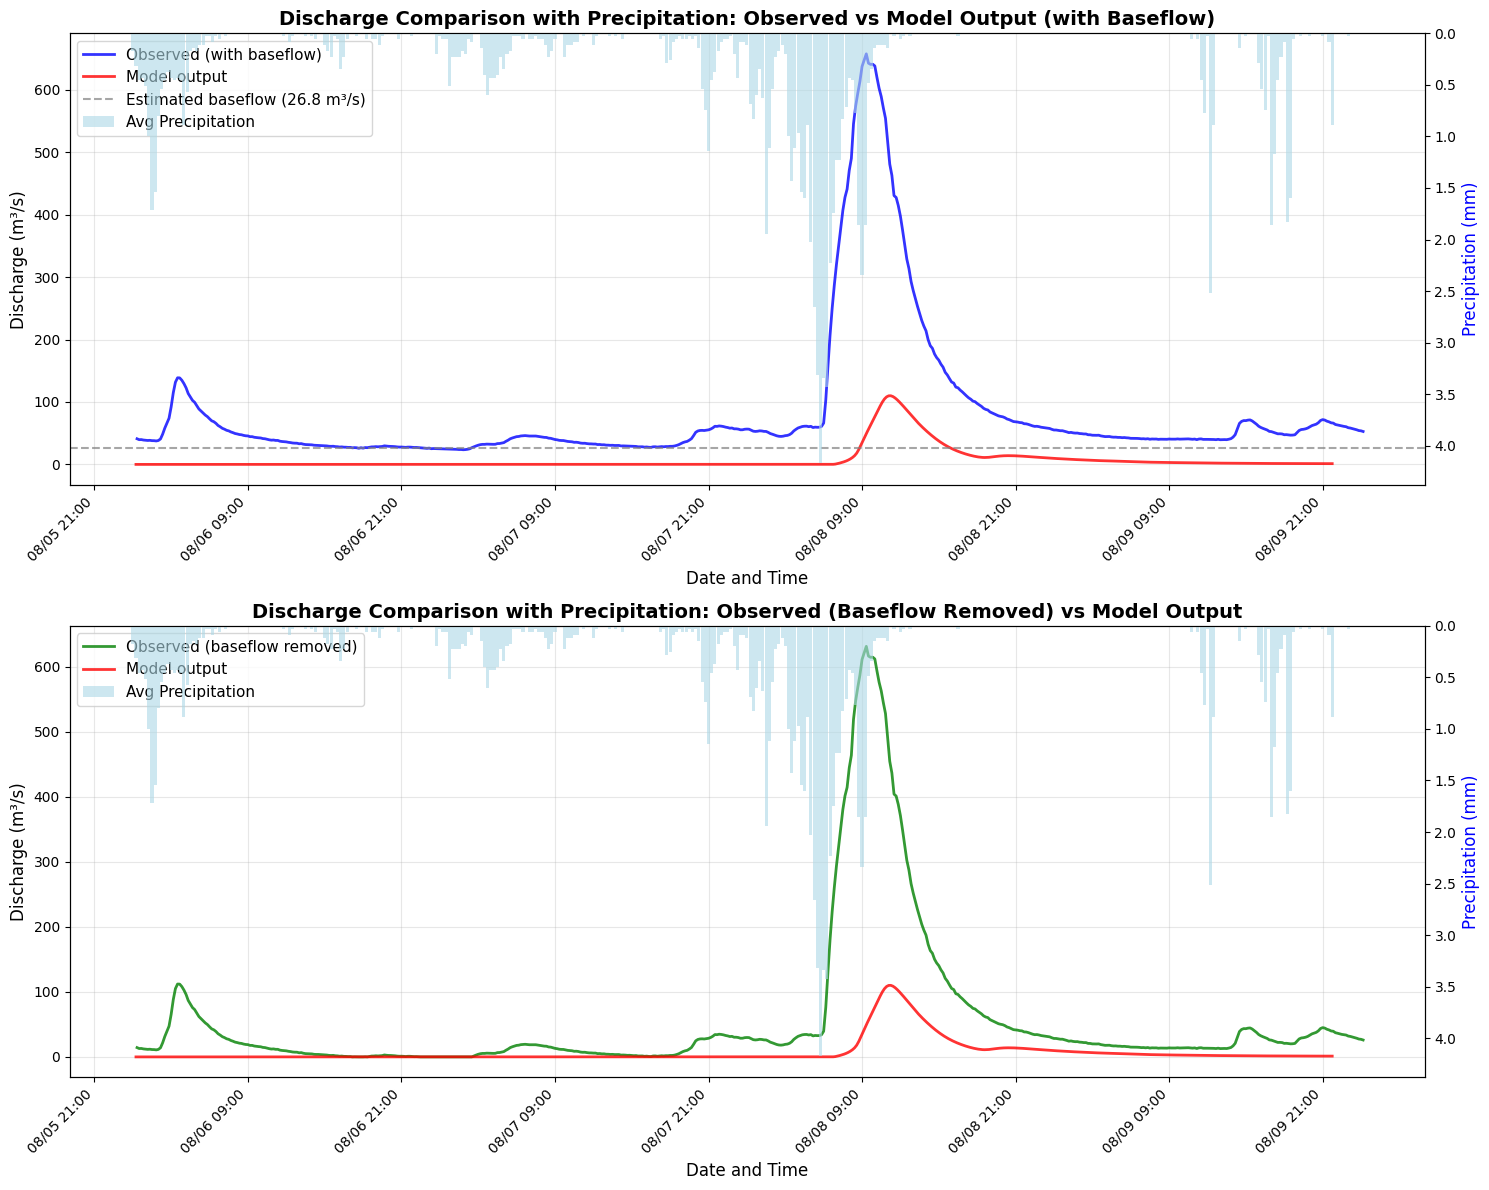


📊 PERFORMANCE STATISTICS:
Common time period: 2023-08-06 00:20:00 to 2023-08-09 21:45:00

Observed discharge statistics (with baseflow):
   Peak: 657.9 m³/s
   Mean: 82.4 m³/s
   Total volume: 27.67 million m³ (10-min intervals)

Observed discharge statistics (baseflow removed):
   Peak: 631.1 m³/s
   Mean: 55.7 m³/s
   Total volume: 18.71 million m³ (10-min intervals)

Model discharge statistics:
   Peak: 110.0 m³/s
   Mean: 7.4 m³/s
   Total volume: 2.49 million m³ (10-min intervals)

Peak discharge comparison (baseflow removed):
   Observed peak: 631.1 m³/s
   Model peak: 110.0 m³/s
   Difference: -82.6%

Precipitation statistics:
   Total precipitation: 94.6 mm
   Maximum precipitation rate: 4.2 mm (15-min)
   Peak precipitation time: 2023-08-08 05:45:00

✅ Discharge comparison analysis with precipitation completed!


In [145]:
# Load model output and create comparison plots
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import argrelmin
import numpy as np

print("📊 LOADING MODEL OUTPUT AND CREATING COMPARISON PLOTS")
print("=" * 65)


# Load model output data
print("📈 Loading model output data...")
model_data = []

with open(model_output_file, 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                time_minutes, discharge = line.split()
                model_data.append({
                    'time_minutes': float(time_minutes),
                    'discharge_m3s': float(discharge)
                })
            except:
                continue

model_df = pd.DataFrame(model_data)
print(f"✅ Model output loaded: {len(model_df):,} records")
print(f"   Time range: {model_df['time_minutes'].min():.0f} to {model_df['time_minutes'].max():.0f} minutes")
print(f"   Discharge range: {model_df['discharge_m3s'].min():.3f} to {model_df['discharge_m3s'].max():.3f} m³/s")

# Convert model time to datetime (starting from flood start date)
model_start_time = pd.to_datetime(flood_start_date)
model_df['datetime'] = model_start_time + pd.to_timedelta(model_df['time_minutes'], unit='m')

print(f"   Model time range: {model_df['datetime'].min()} to {model_df['datetime'].max()}")

# Load precipitation data
print(f"\n🌧️ Loading precipitation data...")
precip_df = pd.read_csv(precip_data_file)

# Convert datetime and calculate average precipitation across all stations
precip_df['Date and Time'] = pd.to_datetime(precip_df['Date and Time'])

# Get all precipitation columns (exclude datetime column)
precip_columns = [col for col in precip_df.columns if col != 'Date and Time']
print(f"   Found {len(precip_columns)} precipitation stations")

# Calculate average precipitation across all stations
precip_df['avg_precip_mm'] = precip_df[precip_columns].mean(axis=1)

print(f"✅ Precipitation data loaded: {len(precip_df):,} records")
print(f"   Time range: {precip_df['Date and Time'].min()} to {precip_df['Date and Time'].max()}")
print(f"   Average precipitation range: {precip_df['avg_precip_mm'].min():.1f} to {precip_df['avg_precip_mm'].max():.1f} mm")

# Calculate baseflow for observed data (using minimum values approach)
print(f"\n🌊 Calculating baseflow for observed discharge...")

# Method 1: Use minimum discharge as baseflow estimate
baseflow_min = flood_stage_data['discharge_m3s'].min()

# Method 2: Use percentile-based approach (5th percentile)
baseflow_percentile = flood_stage_data['discharge_m3s'].quantile(0.05)

# Method 3: Use local minima approach for more accurate baseflow separation
# Sort by time to ensure proper order
obs_sorted = flood_stage_data.sort_values('dateTime').copy()
obs_sorted.reset_index(drop=True, inplace=True)

# Find local minima (simple approach)
window_size = min(20, len(obs_sorted) // 10)  # Adaptive window size
if window_size > 3:
    local_min_indices = argrelmin(obs_sorted['discharge_m3s'].values, order=window_size//2)[0]
    if len(local_min_indices) > 0:
        baseflow_local_min = obs_sorted.loc[local_min_indices, 'discharge_m3s'].median()
    else:
        baseflow_local_min = baseflow_percentile
else:
    baseflow_local_min = baseflow_percentile

# Choose the baseflow separation method (use percentile as it's more robust)
baseflow = baseflow_percentile
print(f"   Baseflow estimate (5th percentile): {baseflow:.1f} m³/s")
print(f"   Baseflow estimate (minimum): {baseflow_min:.1f} m³/s")
print(f"   Baseflow estimate (local minima): {baseflow_local_min:.1f} m³/s")

# Remove baseflow from observed discharge
flood_stage_data['discharge_no_baseflow'] = (flood_stage_data['discharge_m3s'] - baseflow).clip(lower=0)

print(f"✅ Baseflow removed from observed discharge")
print(f"   Original peak discharge: {flood_stage_data['discharge_m3s'].max():.1f} m³/s")
print(f"   Peak discharge without baseflow: {flood_stage_data['discharge_no_baseflow'].max():.1f} m³/s")

# Create comparison plots with precipitation
print(f"\n📊 Creating comparison plots with precipitation...")

# Set up the plotting style
plt.style.use('default')
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Original vs Model discharge with precipitation
ax1 = axes[0]
# Create secondary y-axis for precipitation
ax1_precip = ax1.twinx()

# Plot discharge on primary axis
ax1.plot(flood_stage_data['dateTime'], flood_stage_data['discharge_m3s'], 
         'b-', linewidth=2, label='Observed (with baseflow)', alpha=0.8)
ax1.plot(model_df['datetime'], model_df['discharge_m3s'], 
         'r-', linewidth=2, label='Model output', alpha=0.8)
ax1.axhline(y=baseflow, color='gray', linestyle='--', alpha=0.7, 
           label=f'Estimated baseflow ({baseflow:.1f} m³/s)')

# Plot precipitation as bars on secondary axis (inverted)
ax1_precip.bar(precip_df['Date and Time'], precip_df['avg_precip_mm'], 
               width=0.01, color='lightblue', alpha=0.6, label='Avg Precipitation')
ax1_precip.invert_yaxis()  # Invert so precipitation appears from top

ax1.set_title('Discharge Comparison with Precipitation: Observed vs Model Output (with Baseflow)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date and Time', fontsize=12)
ax1.set_ylabel('Discharge (m³/s)', fontsize=12, color='black')
ax1_precip.set_ylabel('Precipitation (mm)', fontsize=12, color='blue')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_precip.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper left')

ax1.grid(True, alpha=0.3)

# Format x-axis for better readability
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=12))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 2: Baseflow-corrected vs Model discharge with precipitation
ax2 = axes[1]
# Create secondary y-axis for precipitation
ax2_precip = ax2.twinx()

# Plot discharge on primary axis
ax2.plot(flood_stage_data['dateTime'], flood_stage_data['discharge_no_baseflow'], 
         'g-', linewidth=2, label='Observed (baseflow removed)', alpha=0.8)
ax2.plot(model_df['datetime'], model_df['discharge_m3s'], 
         'r-', linewidth=2, label='Model output', alpha=0.8)

# Plot precipitation as bars on secondary axis (inverted)
ax2_precip.bar(precip_df['Date and Time'], precip_df['avg_precip_mm'], 
               width=0.01, color='lightblue', alpha=0.6, label='Avg Precipitation')
ax2_precip.invert_yaxis()  # Invert so precipitation appears from top

ax2.set_title('Discharge Comparison with Precipitation: Observed (Baseflow Removed) vs Model Output', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date and Time', fontsize=12)
ax2.set_ylabel('Discharge (m³/s)', fontsize=12, color='black')
ax2_precip.set_ylabel('Precipitation (mm)', fontsize=12, color='blue')

# Combine legends
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_precip.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper left')

ax2.grid(True, alpha=0.3)

# Format x-axis for better readability
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=12))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Calculate performance statistics
print(f"\n📊 PERFORMANCE STATISTICS:")
print("=" * 50)

# Find overlapping time period for comparison
common_start = max(flood_stage_data['dateTime'].min(), model_df['datetime'].min())
common_end = min(flood_stage_data['dateTime'].max(), model_df['datetime'].max())

print(f"Common time period: {common_start} to {common_end}")

# Filter data for common time period
obs_common = flood_stage_data[(flood_stage_data['dateTime'] >= common_start) & 
                             (flood_stage_data['dateTime'] <= common_end)].copy()
model_common = model_df[(model_df['datetime'] >= common_start) & 
                       (model_df['datetime'] <= common_end)].copy()

if len(obs_common) > 0 and len(model_common) > 0:
    print(f"\nObserved discharge statistics (with baseflow):")
    print(f"   Peak: {obs_common['discharge_m3s'].max():.1f} m³/s")
    print(f"   Mean: {obs_common['discharge_m3s'].mean():.1f} m³/s")
    print(f"   Total volume: {obs_common['discharge_m3s'].sum() * 600 / 1000000:.2f} million m³ (10-min intervals)")
    
    print(f"\nObserved discharge statistics (baseflow removed):")
    print(f"   Peak: {obs_common['discharge_no_baseflow'].max():.1f} m³/s")
    print(f"   Mean: {obs_common['discharge_no_baseflow'].mean():.1f} m³/s")
    print(f"   Total volume: {obs_common['discharge_no_baseflow'].sum() * 600 / 1000000:.2f} million m³ (10-min intervals)")
    
    print(f"\nModel discharge statistics:")
    print(f"   Peak: {model_common['discharge_m3s'].max():.1f} m³/s")
    print(f"   Mean: {model_common['discharge_m3s'].mean():.1f} m³/s")
    print(f"   Total volume: {model_common['discharge_m3s'].sum() * 600 / 1000000:.2f} million m³ (10-min intervals)")
    
    # Peak discharge comparison
    obs_peak = obs_common['discharge_no_baseflow'].max()
    model_peak = model_common['discharge_m3s'].max()
    peak_diff_percent = ((model_peak - obs_peak) / obs_peak) * 100
    
    print(f"\nPeak discharge comparison (baseflow removed):")
    print(f"   Observed peak: {obs_peak:.1f} m³/s")
    print(f"   Model peak: {model_peak:.1f} m³/s")
    print(f"   Difference: {peak_diff_percent:+.1f}%")

# Precipitation statistics
print(f"\nPrecipitation statistics:")
total_precip = precip_df['avg_precip_mm'].sum()
max_precip = precip_df['avg_precip_mm'].max()
print(f"   Total precipitation: {total_precip:.1f} mm")
print(f"   Maximum precipitation rate: {max_precip:.1f} mm (15-min)")
print(f"   Peak precipitation time: {precip_df.loc[precip_df['avg_precip_mm'].idxmax(), 'Date and Time']}")

print(f"\n✅ Discharge comparison analysis with precipitation completed!")